<a href="https://colab.research.google.com/github/povashraful/HBRS_2026_SS_Fundamentals_of_Artificial_Intelligence_for_Robotics/blob/main/Lab2/Hossain_FAIR_HW2(Lab2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import random


final_goal = [5, 5]

max_iteration = 50


grid_size = 6
print(grid_size)

successful_paths = []
total_epoch = 10
epoch = 0
success_state = 0
length_of_path= 0

while epoch < total_epoch:

    start_position = [0, 0]
    iteration = 0
    path = [start_position.copy()]
    print("EPOCH:", epoch)


    while start_position != final_goal and iteration < max_iteration:

        user_input = random.choice(["up", "down", "left", "right"])
        print("EPOCH:----------------", epoch)
        print("Iteration", iteration)

        up = [start_position[0], start_position[1] + 1]
        down = [start_position[0], start_position[1] - 1]
        right = [start_position[0] + 1, start_position[1]]
        left = [start_position[0] - 1, start_position[1]]

        if user_input == "up":
            new_position = up
        elif user_input == "down":
            new_position = down
        elif user_input == "right":
            new_position = right
        else:
            new_position = left

        if 0 <= new_position[0] < grid_size and 0 <= new_position[1] < grid_size:
            start_position = new_position
            print("NEW POSITION:", start_position)
        else:
            print("Out of boundary")

        path.append(start_position.copy())
        iteration += 1
        print("TOTAL ITERATION", iteration)

    if start_position == final_goal:
        print("The walker has found the goal", path)
        print("The length of the path is: ", len(path))
        length_of_path = length_of_path + len(path)
        successful_paths.append(path.copy())

        print("TOTAL LENGTH",length_of_path)
        success_state+=1
        print("SUCCESS STATE: ", success_state)
        print("Probability",success_state/iteration)
        print("Average steps it took to reach the goal",length_of_path/success_state)

    else:
        print("Goal not found")



    epoch += 1
    print("TOTAL EPOCHS", epoch)

6
EPOCH: 0
EPOCH:---------------- 0
Iteration 0
Out of boundary
TOTAL ITERATION 1
EPOCH:---------------- 0
Iteration 1
NEW POSITION: [0, 1]
TOTAL ITERATION 2
EPOCH:---------------- 0
Iteration 2
Out of boundary
TOTAL ITERATION 3
EPOCH:---------------- 0
Iteration 3
Out of boundary
TOTAL ITERATION 4
EPOCH:---------------- 0
Iteration 4
Out of boundary
TOTAL ITERATION 5
EPOCH:---------------- 0
Iteration 5
NEW POSITION: [0, 2]
TOTAL ITERATION 6
EPOCH:---------------- 0
Iteration 6
NEW POSITION: [0, 3]
TOTAL ITERATION 7
EPOCH:---------------- 0
Iteration 7
NEW POSITION: [0, 4]
TOTAL ITERATION 8
EPOCH:---------------- 0
Iteration 8
NEW POSITION: [0, 3]
TOTAL ITERATION 9
EPOCH:---------------- 0
Iteration 9
NEW POSITION: [1, 3]
TOTAL ITERATION 10
EPOCH:---------------- 0
Iteration 10
NEW POSITION: [1, 4]
TOTAL ITERATION 11
EPOCH:---------------- 0
Iteration 11
NEW POSITION: [1, 3]
TOTAL ITERATION 12
EPOCH:---------------- 0
Iteration 12
NEW POSITION: [0, 3]
TOTAL ITERATION 13
EPOCH:--------

##---------------NOW ----------------------------------------------------------
I was unsure on which was the best method of plotting the graph- So, I took some help of LLMs (mainly ChatGPT), to make the graph visually appealing and easier to understand. I modified the code to make it fit for my purpose


NB. I only used LLM for the plot graph only- nothing else.


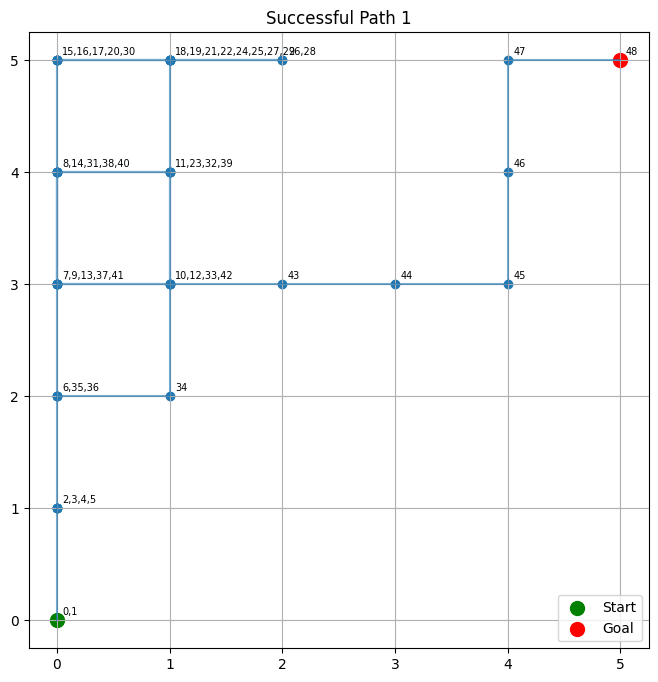

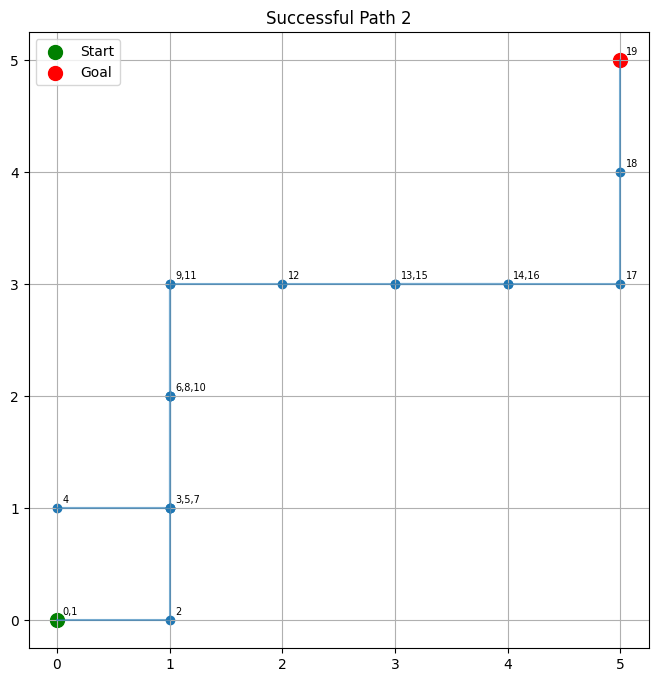

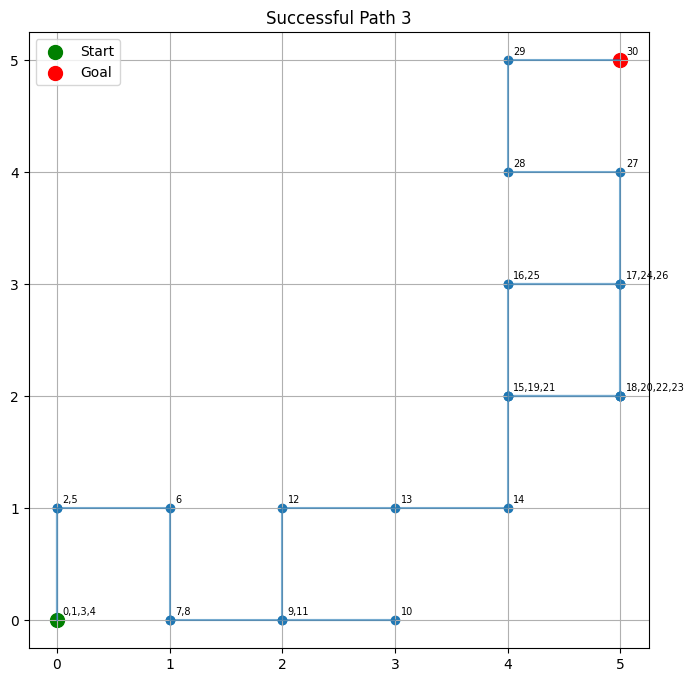

In [43]:
import matplotlib.pyplot as plt

plt.style.use("default")

if len(successful_paths) == 0:


    plt.figure(figsize=(8, 8))

    plt.text(0.5, 0.5, "No Success Yet",
             fontsize=20,
             ha='center', va='center')

    plt.title("Monte Carlo Result")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.axis('off')   # hide axes

    plt.show()

else:


    for idx, path in enumerate(successful_paths):

      x = [p[0] for p in path]
      y = [p[1] for p in path]

      plt.figure(figsize=(8, 8))

      plt.scatter(x, y)
      plt.plot(x, y, alpha=0.6)

      # 🔹 FIX: group steps per position
      visited_steps = {}

      for step, position in enumerate(path):
          pos = tuple(position)

          if pos not in visited_steps:
              visited_steps[pos] = []

          visited_steps[pos].append(step)


      for pos, steps in visited_steps.items():
          x_pos, y_pos = pos

          unique_steps = sorted(set(steps))
          label = ",".join(str(s) for s in unique_steps)

          plt.text(x_pos + 0.05, y_pos + 0.05,
                  label,
                  fontsize=7)

      plt.scatter(0, 0, color="green", label="Start", s=100)
      plt.scatter(5, 5, color="red", label="Goal", s=100)

      plt.title(f"Successful Path {idx + 1}")
      plt.legend()
      plt.grid(True)

      plt.show()

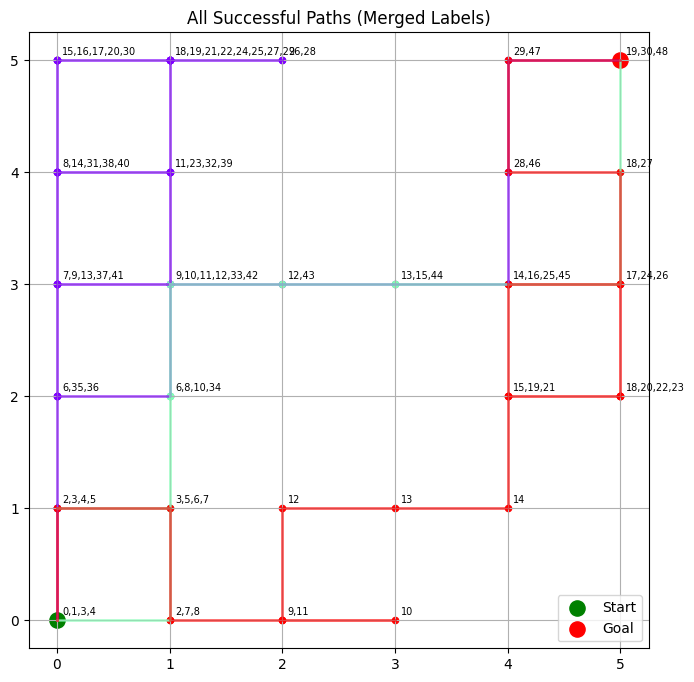

In [39]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("default")

plt.figure(figsize=(8, 8))

colors = plt.cm.rainbow(np.linspace(0, 1, len(successful_paths)))


visited_steps_global = {}

for idx, path in enumerate(successful_paths):

    x = [p[0] for p in path]
    y = [p[1] for p in path]

    color = colors[idx]

    plt.plot(x, y, color=color, linewidth=2, alpha=0.6)
    plt.scatter(x, y, color=color, s=20)


    for step, position in enumerate(path):
        pos = tuple(position)

        if pos not in visited_steps_global:
            visited_steps_global[pos] = []

        visited_steps_global[pos].append(step)



for pos, steps in visited_steps_global.items():

    x_pos, y_pos = pos

    unique_steps = sorted(set(steps))

    label = ",".join(str(s) for s in unique_steps)

    plt.text(x_pos + 0.05, y_pos + 0.05,
             label,
             fontsize=7,
             color="black")



plt.scatter(0, 0, color="green", label="Start", s=120)
plt.scatter(5, 5, color="red", label="Goal", s=120)

plt.title("All Successful Paths (Merged Labels)")
plt.legend()
plt.grid(True)
plt.show()